In [170]:
import numpy as np
import networkx as nx
import pprint

from spidercss.cat_at_origin import *
from spidercss.utils import load_qecc
from spidercss.utils import load_FAO_circ
from resource_scheduling import plan_resource_aware_reuse


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{0: 95, 1: 96, 2: 97, 3: 98, 4: 99, 5: 100, 6: 101, 7: 102, 8: 103, 9: 104, 10: 105, 11: 106, 12: 107, 13: 108, 14: 109, 15: 110, 16: 111, 17: 112, 18: 113, 19: 114, 20: 115, 21: 116, 22: 117, 23: 118, 24: 119, 25: 120, 26: 121, 27: 122, 28: 123, 29: 124, 30: 125, 31: 126, 32: 127, 33: 128, 34: 129, 35: 130, 36: 131, 37: 132, 38: 133, 39: 134, 40: 135, 41: 136, 42: 137, 43: 138, 44: 139, 45: 140, 46: 141, 47: 142, 48: 143, 49: 144, 50: 145, 51: 146, 52: 147, 53: 148, 54: 149, 55: 150, 56: 151, 57: 152, 58: 153, 59: 154, 60: 155, 61: 156, 62: 157, 63: 158, 64: 159, 65: 160, 66: 161, 67: 162, 68: 163, 69: 164, 70: 165, 71: 166, 72: 167, 73: 168, 74: 169, 75: 170, 76: 171, 77: 172, 78: 173, 79: 174, 80: 175, 81: 176, 82: 177, 83: 178, 84: 179, 85: 180, 86: 181, 87: 182, 88: 183, 89: 184, 90: 185, 91: 186, 92: 187, 93: 188, 94: 189, 95: 190, 96: 191, 97: 192, 98: 193, 99: 194, 100: 195, 101: 196, 102: 197, 103: 198, 104: 199, 105: 200, 106: 201, 107: 202, 108: 203, 109: 204, 110: 205, 111:

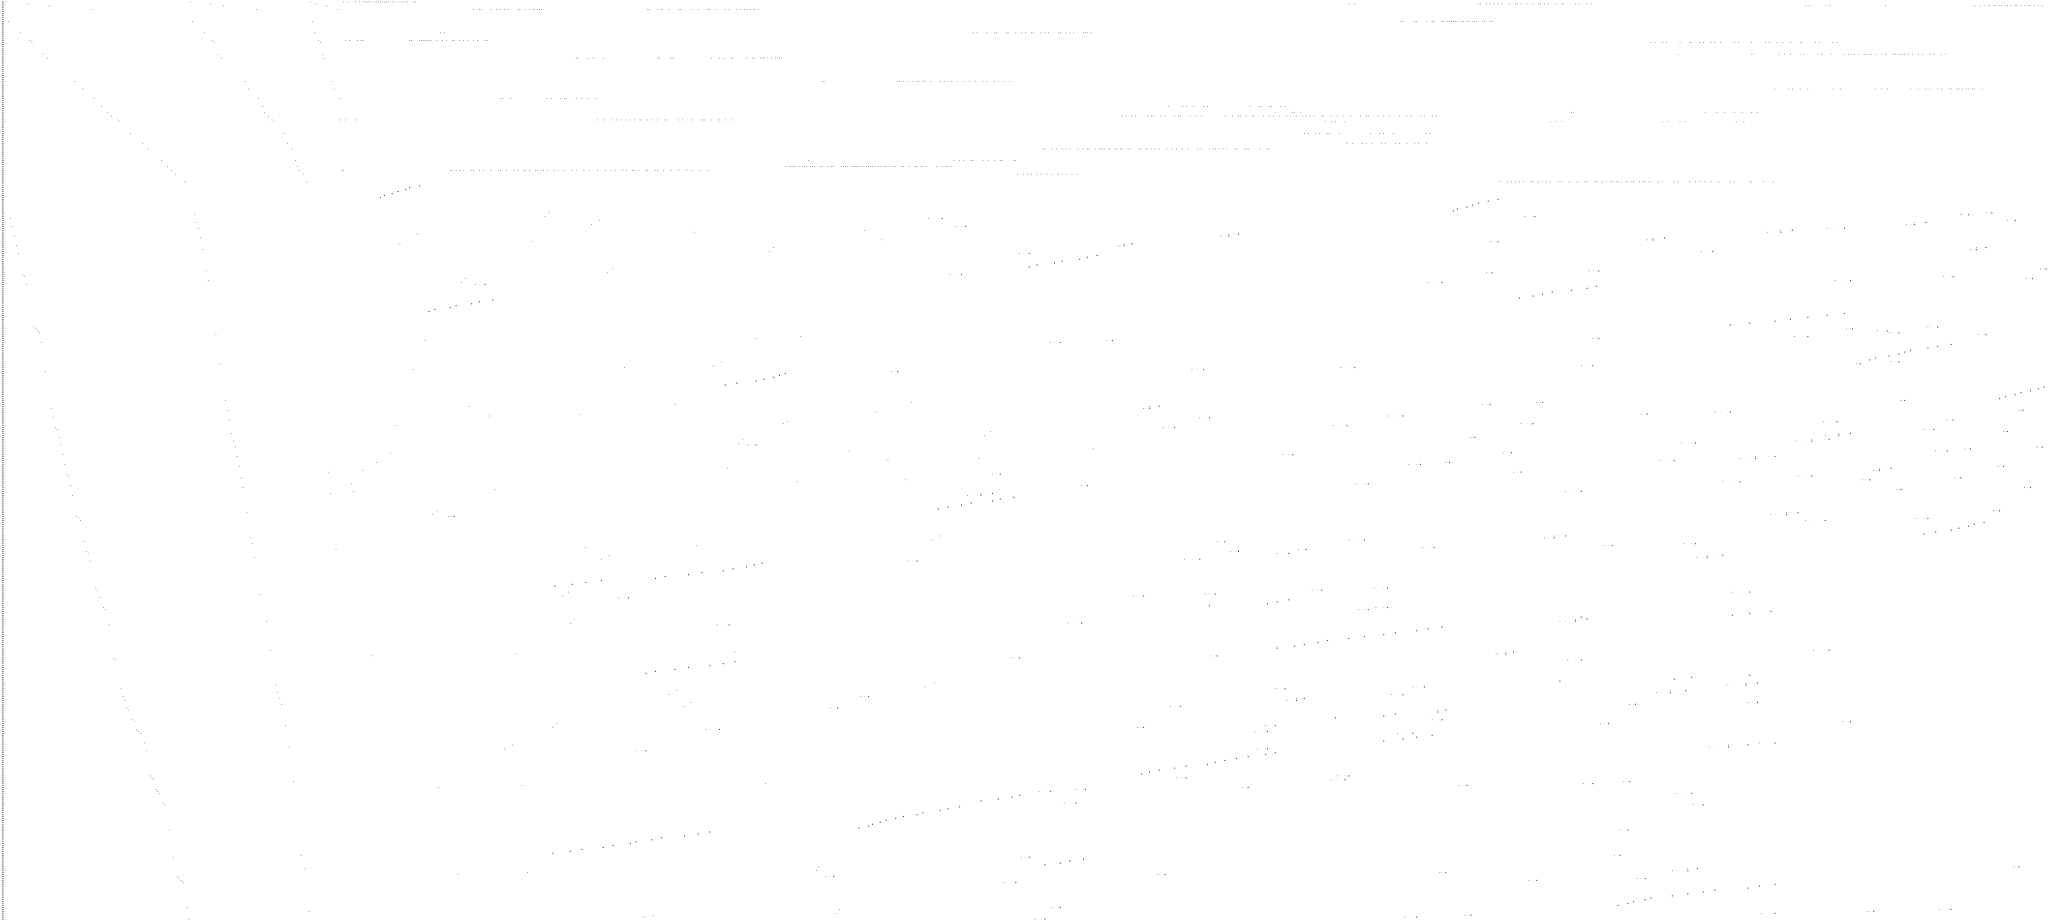

In [189]:
code = "95_1_7"
circ = load_FAO_circ(code)
circ.diagram('timeline-svg')

In [190]:
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code, "FAO")
t = d // 2
basis = "X" if code in ("15_1_3", "49_1_5", "95_1_7") else "Z"
if basis == "X":
    H_x, H_z = H_z, H_x
    L_x, L_z = L_z, L_x

In [191]:
circuit = circ.copy()

circuit.append("M" + basis, range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
flags = samples[:, :-H_z.shape[1]].astype(int)
meas_samples = samples[:, -H_z.shape[1]:]
print(np.all(flags == 0))
print(np.all(meas_samples @ H_z.T % 2 == 0))
print(np.all(meas_samples @ L_z.T % 2 == 0))

True
True
True


In [192]:
from spidercss.utils import _layer_cnot_circuit

raw_cnots = [l for (name, l, _) in circ.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num Flags:", circ.num_qubits - H_z.shape[1])
print("Num qubits:", circ.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

Num CX: 1175
Num Flags: 380
Num qubits: 475
Depth: 386


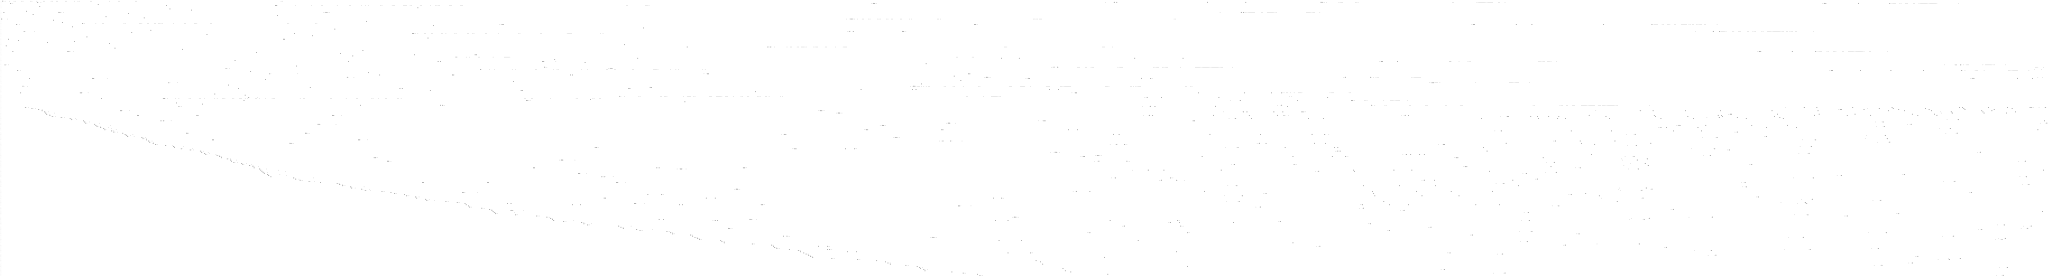

In [193]:
reuse_plan = plan_resource_aware_reuse(
    circ, H_x.shape[1], heuristic="greedy", max_time_seconds=300.0,
    target=ReuseTarget.QUBITS,
)
circ_with_reuse = reuse_plan.circuit
circ_with_reuse.diagram('timeline-svg')

In [194]:
from spidercss.utils import _layer_cnot_circuit

raw_cnots = [l for (name, l, _) in circ_with_reuse.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num Flags:", circ_with_reuse.num_qubits - H_z.shape[1])
print("Num qubits:", circ_with_reuse.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))

Num CX: 1175
Num Flags: 151
Num qubits: 246
Depth: 649
